## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


In [69]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

In [70]:
conn = sqlite3.connect('zippedData/im.db')

In [71]:
cur = conn.cursor()

In [72]:
df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")

# **Data Understanding**
- For our analysis, the two most relevant data files we used are:
    - im.db, specifically the movie_basics and movie_ratings tables
    - bom.movie_gross.csv.gz 

### Bom.movie csv 

In [73]:
df.shape

(3387, 5)

In [74]:
df.dtypes

title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [75]:
df.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


- studio has missing data 
- domestic gross has missing data 
- foreign gross has missing data 
- foreign gross should be float not object 
- year data to be datetime 


In [77]:
df.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [78]:
# Missing values %
def missing(df,col):
    missing = (df[col].isna().sum()/len(df))*100
    if missing == 0:
        print(f" we have {missing} % missing from {col}")
    elif missing < 5:
        print(f" we have {missing} % missing from {col} we can go ahead and either drop the rows or fill in the missing values")
    elif missing < 30:
        print(f" we have {missing} % missing from {col} we can go ahead and fill in the missing values")
    else :
        print(f" we have {missing} % missing from {col} we can go ahead and drop the column or consider other alternatives")

In [79]:
missing(df,'studio')

 we have 0.14762326542663123 % missing from studio we can go ahead and either drop the rows or fill in the missing values


In [80]:
missing(df,'domestic_gross')

 we have 0.8266902863891349 % missing from domestic_gross we can go ahead and either drop the rows or fill in the missing values


In [81]:
missing(df, 'foreign_gross')

 we have 39.85828166519043 % missing from foreign_gross we can go ahead and drop the column or consider other alternatives


In [82]:
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [83]:
df.tail()

,title,studio,domestic_gross,foreign_gross,year
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018
3386,An Actor Prepares,Grav.,1700.0,NaN,2018


### Movie Data ERD 
![alt text](movie_data_erd.jpeg)


In [84]:
# im.db movie_basics 
query = pd.read_sql(""" 
SELECT * FROM movie_basics 
LIMIT 5;
""", conn)

query

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [85]:
# im.db movie_ratings

query_2 = pd.read_sql("""
SELECT * FROM movie_ratings 
LIMIT 5;
""", conn)

query_2

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


# **Data Cleaning**

As we saw in our above inspection the following cleaning tasks were to be completed to have a clean data set ready for analysis
1. Bom.movie csv 
    - foreign gross d type needs to be changed from object to float 
    - studio has 0.14% missing data - we can drop those rows 
    - domestic gross has 0.82% if missing data - we can drop those rows 

In [86]:
df['foreign_gross'].unique()

array(['652000000', '691300000', '664300000', ..., '530000', '256000',
       '30000'], dtype=object)

In [87]:
# change foreign gross d type 
df['foreign_gross'] = df['foreign_gross'].str.replace(',', '').astype('float')


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


In [89]:
df = df.dropna(subset=['studio'])

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3382 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3382 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2033 non-null   float64
 4   year            3382 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 158.5+ KB


In [91]:
# Dropping if any rows where BOTH domestic_gross and foreign_gross are missing 
# Without either it is difficult to do any meaningful analysis 
df = df.dropna(subset=['domestic_gross','foreign_gross'], how='all')

In [92]:
# seems that no such entry exists where both foreign or domestic gross is missing
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3382 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3382 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2033 non-null   float64
 4   year            3382 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 158.5+ KB


In [93]:
df.isna().sum()
# since there is 26 missing values in the domestic gross column
# best option is to drop these missing value rows 

title                0
studio               0
domestic_gross      26
foreign_gross     1349
year                 0
dtype: int64

In [94]:
df = df.dropna(subset=['domestic_gross'])

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3356 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3356 non-null   object 
 1   studio          3356 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2007 non-null   float64
 4   year            3356 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 157.3+ KB


In [96]:
df.describe()

,domestic_gross,foreign_gross,year
count,3.356000e+03,2.007000e+03,3356.000000
mean,2.877149e+07,7.579038e+07,2013.970203
std,6.700694e+07,1.381796e+08,2.479064
min,1.000000e+02,6.000000e+02,2010.000000
25%,1.200000e+05,3.900000e+06,2012.000000
50%,1.400000e+06,1.940000e+07,2014.000000
75%,2.795000e+07,7.595000e+07,2016.000000
max,9.367000e+08,9.605000e+08,2018.000000


In [97]:
df[df.duplicated(subset=['title'])]

,title,studio,domestic_gross,foreign_gross,year
3045,Bluebeard,WGUSA,43100.0,NaN,2017


<AxesSubplot:xlabel='domestic_gross'>

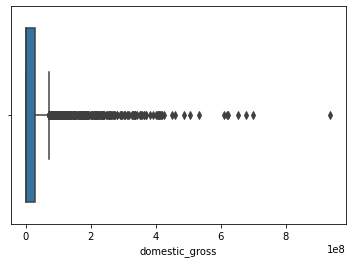

In [98]:
sns.boxplot(x=df['domestic_gross'])

<AxesSubplot:xlabel='domestic_gross', ylabel='Count'>

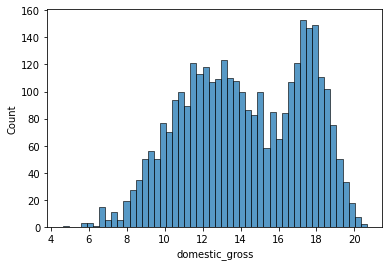

In [99]:
sns.histplot(np.log1p(df['domestic_gross']), bins=50)

In [100]:
Q1 = df['domestic_gross'].quantile(0.25)
Q3 = df['domestic_gross'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['domestic_gross'] < lower) | (df['domestic_gross'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 406


In [101]:
Q1 = df['foreign_gross'].quantile(0.25)
Q3 = df['foreign_gross'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['foreign_gross'] < lower) | (df['foreign_gross'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 256


**Note**: Although domestic gross and foreign gross both have outliers in our dataset we made the decision to retain them. This is because financial data like box office gross is meaningful data and is quite realistic

2. Movie ERD

In [102]:
query = pd.read_sql("""
SELECT name FROM sqlite_master WHERE type='table';
""", conn)
query

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [103]:
movie_basics = pd.read_sql("""SELECT * FROM movie_basics;""", conn)
movie_basics.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

In [104]:
movie_ratings = pd.read_sql("""
SELECT * FROM movie_ratings;""", conn)
movie_basics.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

# **Exploratory Data Analysis**

## Business Question: Which Genres Perform Best Financially (Domestic audience)
 - In order to explore this Business Q, the movie_basics table needs to be merged with the bom.movie csv 
 - Since IMDB contains a much broader set of films than what's tracked at the box office, we merged the two datasets on both **title** and **release year** to ensure we matched the correct 
version of each film (avoiding false matches between unrelated films that happen 
to share a title).

In [105]:
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


In [106]:
query = pd.read_sql(""" 
SELECT * FROM movie_basics 
LIMIT 5;
""", conn)

query

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [107]:
# merge both tables 

movie_basics_df = pd.read_sql("""
SELECT * FROM movie_basics;""", conn)

In [108]:
merged_df = pd.merge(
    movie_basics_df, 
    df,
    left_on='primary_title',
    right_on='title',
    how="inner")

In [109]:
merged_df.head(20)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,studio,domestic_gross,foreign_gross,year
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",Wazir,Relbig.,1100000.0,NaN,2016
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",On the Road,IFC,744000.0,8000000.0,2012
2,tt2404548,On the Road,On the Road,2011,90.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
3,tt3872966,On the Road,On the Road,2013,87.0,Documentary,On the Road,IFC,744000.0,8000000.0,2012
4,tt4339118,On the Road,On the Road,2014,89.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
5,tt5389486,On the Road,On the Road,2015,39.0,Documentary,On the Road,IFC,744000.0,8000000.0,2012
6,tt5647250,On the Road,On the Road,2016,121.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
7,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",The Secret Life of Walter Mitty,Fox,58200000.0,129900000.0,2013
8,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",A Walk Among the Tombstones,Uni.,26300000.0,26900000.0,2014
9,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",Jurassic World,Uni.,652300000.0,1019.4,2015


In [110]:
merged_df.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,studio,domestic_gross,foreign_gross,year
3336,tt8404272,How Long Will I Love U,Chao shi kong tong ju,2018,101.0,Romance,How Long Will I Love U,WGUSA,747000.0,82100000.0,2018
3337,tt8427036,Helicopter Eela,Helicopter Eela,2018,135.0,Drama,Helicopter Eela,Eros,72000.0,NaN,2018
3338,tt8851262,Spring Fever,Spring Fever,2019,NaN,"Comedy,Horror",Spring Fever,Strand,10800.0,150000.0,2010
3339,tt9078374,Last Letter,"Ni hao, Zhihua",2018,114.0,"Drama,Romance",Last Letter,CL,181000.0,NaN,2018
3340,tt9151704,Burn the Stage: The Movie,Burn the Stage: The Movie,2018,84.0,"Documentary,Music",Burn the Stage: The Movie,Trafalgar,4200000.0,16100000.0,2018


In [111]:
merged_df.duplicated().sum()

0

In [112]:
merge = pd.merge(movie_basics_df, df[['title','domestic_gross', 'foreign_gross']],
                 left_on='primary_title',
                 right_on='title',
                 how="inner")

merge.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,domestic_gross,foreign_gross
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",Wazir,1100000.0,NaN
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",On the Road,744000.0,8000000.0
2,tt2404548,On the Road,On the Road,2011,90.0,Drama,On the Road,744000.0,8000000.0
3,tt3872966,On the Road,On the Road,2013,87.0,Documentary,On the Road,744000.0,8000000.0
4,tt4339118,On the Road,On the Road,2014,89.0,Drama,On the Road,744000.0,8000000.0


In [113]:
merge.isna().sum()

movie_id              0
primary_title         0
original_title        0
start_year            0
runtime_minutes     167
genres               40
title                 0
domestic_gross        0
foreign_gross      1322
dtype: int64

Note - ran into unexpected duplication and Nan values when merging. Next strategy employed is to change the column_name in the csv to match the column name on the movie_basics table to merge easily

In [114]:
df_q_1 = df.rename(columns={'title': 'primary_title', 'year': 'start_year'})

merge_1 = pd.merge(movie_basics_df, 
                    df_q_1[['primary_title', 'start_year', 'domestic_gross', 'foreign_gross']],
                    on=['primary_title', 'start_year'],
                    how="inner")


In [115]:
merge_1.head(20)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,domestic_gross,foreign_gross
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",1100000.0,NaN
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",744000.0,8000000.0
2,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",58200000.0,129900000.0
3,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",26300000.0,26900000.0
4,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",652300000.0,1019.4
5,tt0376136,The Rum Diary,The Rum Diary,2011,119.0,"Comedy,Drama",13100000.0,10800000.0
6,tt0376479,American Pastoral,American Pastoral,2016,108.0,"Crime,Drama",544000.0,NaN
7,tt0383010,The Three Stooges,The Three Stooges,2012,92.0,"Comedy,Family",44300000.0,10500000.0
8,tt0398286,Tangled,Tangled,2010,100.0,"Adventure,Animation,Comedy",200800000.0,391000000.0
9,tt0401729,John Carter,John Carter,2012,132.0,"Action,Adventure,Sci-Fi",73100000.0,211100000.0


In [116]:
merge_1.isna().sum()

movie_id             0
primary_title        0
original_title       0
start_year           0
runtime_minutes     10
genres               2
domestic_gross       0
foreign_gross      595
dtype: int64

In [117]:
merge_1['primary_title'].value_counts().head(30)

The Wall             3
Truth or Dare        2
Colette              2
Sisters              2
Spotlight            2
Extraction           2
Denial               2
Burlesque            2
Abduction            2
True Story           2
The Journey          2
The Bounty Hunter    2
The Guardians        2
The Negotiation      2
Stronger             2
Three                2
The Forest           2
Cyrus                2
The Bay              2
Dancer               2
Leap Year            2
The Walk             2
The Call             2
Gone                 2
The Night Before     2
Lights Out           2
The Other Side       2
A Better Life        2
Sleepless            2
Big Eyes             2
Name: primary_title, dtype: int64

In [118]:
print(len(movie_basics_df), len(merge_1))

146144 1863


In [119]:
print(len(df))

3356


### **Handling Multiple Genres per Film**

Many films in this dataset are tagged with more than one genre (e.g. "Action, 
Crime, Drama"). Since IMDB does not confirm that genres are listed in order of 
importance, we chose the **first listed genre** for each film as a simplifying 
label for our primary analysis, rather than assuming it represents the film's 
single "true" genre. This is a methodology choice, not a confirmed 
classification from IMDB — we revisit this assumption later with a cross-check 
using an alternate method.

In [120]:
merge_1['primary_genre'] = merge_1['genres'].str.split(',').str[0]

In [121]:
merge_1.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
domestic_gross     float64
foreign_gross      float64
primary_genre       object
dtype: object

In [122]:
merge_1.head(10)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,domestic_gross,foreign_gross,primary_genre
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",1100000.0,NaN,Action
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",744000.0,8000000.0,Adventure
2,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",58200000.0,129900000.0,Adventure
3,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",26300000.0,26900000.0,Action
4,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",652300000.0,1019.4,Action
5,tt0376136,The Rum Diary,The Rum Diary,2011,119.0,"Comedy,Drama",13100000.0,10800000.0,Comedy
6,tt0376479,American Pastoral,American Pastoral,2016,108.0,"Crime,Drama",544000.0,NaN,Crime
7,tt0383010,The Three Stooges,The Three Stooges,2012,92.0,"Comedy,Family",44300000.0,10500000.0,Comedy
8,tt0398286,Tangled,Tangled,2010,100.0,"Adventure,Animation,Comedy",200800000.0,391000000.0,Adventure
9,tt0401729,John Carter,John Carter,2012,132.0,"Action,Adventure,Sci-Fi",73100000.0,211100000.0,Action


In [123]:
merge_1['primary_genre'].value_counts()

Action         521
Comedy         396
Drama          333
Biography      168
Adventure      166
Documentary     81
Crime           79
Horror          67
Animation       18
Fantasy          9
Thriller         8
Romance          7
Mystery          5
Music            2
Sci-Fi           1
Name: primary_genre, dtype: int64

### Ensuring Reliable Comparisons Across Genres

Some genres in our merged dataset are represented by only a handful of films. 
Averaging financial performance across a very small sample can be misleading — 
a single unusually successful or unsuccessful film can swing the average and 
create a false impression of how that genre performs overall.

To keep our comparisons meaningful, we only included the top 6 genres in our merged dataset.

In [124]:
merge_1['start_year'].describe()

count    1863.000000
mean     2014.011272
std         2.514700
min      2010.000000
25%      2012.000000
50%      2014.000000
75%      2016.000000
max      2018.000000
Name: start_year, dtype: float64

In [125]:
financial = merge_1.groupby('primary_genre')['domestic_gross'].mean().sort_values(ascending=False)

financial 

primary_genre
Adventure      8.962618e+07
Action         6.965484e+07
Mystery        6.705660e+07
Animation      5.006581e+07
Horror         3.969576e+07
Comedy         2.742875e+07
Biography      2.635948e+07
Crime          2.099816e+07
Drama          1.840538e+07
Romance        9.264714e+06
Thriller       6.950650e+06
Documentary    6.702051e+06
Fantasy        4.544667e+06
Music          1.836000e+06
Sci-Fi         7.800000e+04
Name: domestic_gross, dtype: float64

In [126]:
financial.head(10)

primary_genre
Adventure    8.962618e+07
Action       6.965484e+07
Mystery      6.705660e+07
Animation    5.006581e+07
Horror       3.969576e+07
Comedy       2.742875e+07
Biography    2.635948e+07
Crime        2.099816e+07
Drama        1.840538e+07
Romance      9.264714e+06
Name: domestic_gross, dtype: float64

In [127]:
financial_millions = (financial / 1_000_000).round(1)
financial_millions

primary_genre
Adventure      89.6
Action         69.7
Mystery        67.1
Animation      50.1
Horror         39.7
Comedy         27.4
Biography      26.4
Crime          21.0
Drama          18.4
Romance         9.3
Thriller        7.0
Documentary     6.7
Fantasy         4.5
Music           1.8
Sci-Fi          0.1
Name: domestic_gross, dtype: float64

In [128]:
top6 = financial_millions.head(6)

### **Visualization**

We converted average domestic gross from raw dollar figures into millions 
(e.g. $89,626,180 → $89.6M) to make the chart easier to read for a non-technical 
audience. The chart below shows the top 6 genres by average domestic gross, 
based only on genres with a reliable sample size of films.

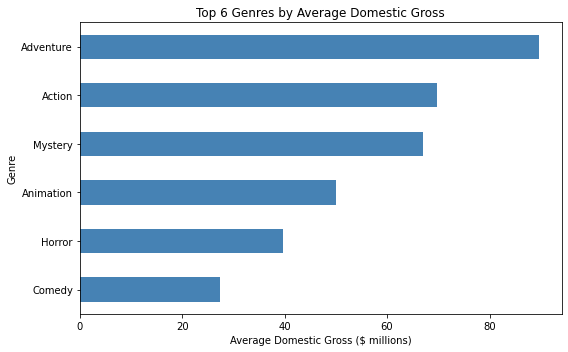

In [129]:
plt.figure(figsize=(8, 5))
top6.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 6 Genres by Average Domestic Gross')
plt.xlabel('Average Domestic Gross ($ millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**What this chart shows**: Average domestic box office earnings for the top 6 genres, in millions of dollars. Adventure leads at ~$89.6M per film, followed by Action at ~$69.7M. We used averages (not totals) and only included genres with at least 5 films, so the comparison is fair.

In [130]:
recent = merge_1[merge_1['start_year'] >= 2014]

recent_genre_counts = recent['primary_genre'].value_counts()
recent_reliable_genres = recent_genre_counts[recent_genre_counts >= 5].index

recent_financial = recent[recent['primary_genre'].isin(recent_reliable_genres)] \
    .groupby('primary_genre')['domestic_gross'].mean().sort_values(ascending=False)

recent_financial_millions = (recent_financial / 1_000_000).round(1)
recent_financial_millions.head(6)

primary_genre
Adventure    82.7
Action       74.5
Horror       44.3
Animation    35.0
Biography    25.4
Comedy       24.3
Name: domestic_gross, dtype: float64

In [131]:
comparison = pd.DataFrame({
    'all_years': financial_millions,
    'recent_years': recent_financial_millions
})
comparison.head(10)

,all_years,recent_years
Action,69.7,74.5
Adventure,89.6,82.7
Animation,50.1,35.0
Biography,26.4,25.4
Comedy,27.4,24.3
Crime,21.0,18.4
Documentary,6.7,6.8
Drama,18.4,17.9
Fantasy,4.5,0.5
Horror,39.7,44.3


**All years vs. recent years**: We checked whether our genre rankings held up using only films from 2014 onward, not just the full 2010–2018 dataset. Adventure and Action stayed on top in both, confirming the finding is stable. Horror trended up in recent years, while Animation trended down.

### Summary 

Based on average domestic gross per film, Adventure and Action are the two strongest-performing genres. Since a decade-long average can be skewed by outdated trends, we re-ran the analysis using only films released from 2014 onward. The results held up with Adventure and Action remained the top two genres, with comparable average gross figures (82.7M and
74.5M respectively), giving us confidence this is a stable pattern rather than a temporary spike driven by older data.
Two notable shifts worth flagging:
- Horror's average gross increased in recent years (44.3M), suggesting growing commercial momentum.
- Animation's average declined (35.0M), suggesting its appetite among audiences may be declining

### Cross-Check: Comparing Against an "Exploded" Genre Approach

As an alternative to using each film's first listed genre, we also tested an 
approach where films with multiple genres are counted under **all** of their 
listed genres (an "exploded" genre column). This avoids the assumption that 
the first genre listed is more important than the others, though it means a 
film's revenue is counted once for each genre it's tagged with, rather than 
just once overall.

In [132]:
merge_1_exploded = merge_1.copy()
merge_1_exploded['genres'] = merge_1_exploded['genres'].str.split(',')
merge_1_exploded = merge_1_exploded.explode('genres')

In [133]:
exploded_genre_counts = merge_1_exploded['genres'].value_counts()
exploded_reliable_genres = exploded_genre_counts[exploded_genre_counts >= 5].index

merge_1_exploded_reliable = merge_1_exploded[merge_1_exploded['genres'].isin(exploded_reliable_genres)]

In [134]:
exploded_financial = merge_1_exploded_reliable.groupby('genres')['domestic_gross'].mean().sort_values(ascending=False)
exploded_financial_millions = (exploded_financial / 1_000_000).round(1)
exploded_financial_millions.head(6)

genres
Sci-Fi       132.7
Animation    115.4
Adventure    112.1
Action        69.7
Fantasy       67.2
Family        60.7
Name: domestic_gross, dtype: float64

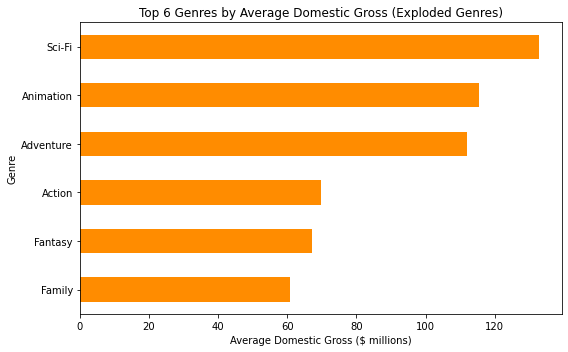

In [135]:
top6_exploded = exploded_financial_millions.head(6)

plt.figure(figsize=(8, 5))
top6_exploded.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 6 Genres by Average Domestic Gross (Exploded Genres)')
plt.xlabel('Average Domestic Gross ($ millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Result of Cross-Check

Unlike our earlier median/recent-years checks, this comparison revealed a 
meaningful difference. Under the exploded-genre approach, **Sci-Fi, Animation, 
and Fantasy** rise sharply in the rankings, genres that were underrepresented 
or excluded entirely under the first-listed-genre method, since they often 
appear as a *secondary* genre tag on major franchise films (e.g. an 
action-adventure movie also tagged Sci-Fi).

# **Recommendation**
Only **Adventure and Action** remain in the top tier under both methods, making 
them the most consistently strong recommendation regardless of how multi-genre 
films are handled. Genres like Sci-Fi, Animation, and Fantasy show strong 
potential too, but their ranking is more sensitive to methodology, and should 
be treated as a secondary, less certain finding rather than as confident as 
our Adventure/Action recommendation.
